In [ ]:
import os
import sys
import warnings
from pathlib import Path
from typing import Dict

import numpy as np

# Silence warnings
warnings.filterwarnings("ignore")

# Add project paths
cwd = Path.cwd()
sys.path.insert(0, str(cwd))
sys.path.append(str(cwd.parent))

# Project imports
from training.gaussian_process import *
from evaluate_memory_allocation_methods import HPCMemoryEvaluator, WeightingConfig
import evaluate_memory_allocation_methods
from evaluation_metrics import JobCost


# Evaluating resource allocation models for assembly HPC jobs

Accurately predicting resource use is essential in shared HPC systems. When memory estimates are off, throughput of a pipeline is limited or results in waste resources. Choosing the right model requires evaluation methods that reflect how systems actually run.

From a user’s view, a failed job means lost time and job caring. From an HPC administrator’s view, it means resource duplication when the system retries. Both translate into wasted compute.

In this analysis, we tested several models and evaluation metrics to understand which approach best supports real-world HPC workloads.

---

## Standard metrics tell only part of the story

We started with the usual indicators — MAE, RMSE, and R² — and included a safety/efficiency trade-off metric.

At first, the Random Forest model looked best. It achieved the lowest error and offered a good balance between under- and over-prediction.

In [4]:
## From kmer frequency
import argparse
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict

from sklearn.preprocessing import OneHotEncoder

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

sns.set(style="whitegrid")


def load_stats(stats_path: Path) -> pd.DataFrame:
    # try load with first column as index (common when saving DataFrame.to_csv())
    df = pd.read_csv(stats_path, index_col=0)
    # ensure numeric columns only (drop metrics that are non-numeric)
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


def load_metadata(meta_path: Path) -> pd.DataFrame:
    df = pd.read_csv(meta_path)
    # try common names
    if "srr_id" in df.columns and "peak_mem_in_gbs" in df.columns:
        df2 = df.set_index("srr_id")[["peak_mem_in_gbs"]]
        return df2

    # fallback: try to find the best column names
    candidates = [c for c in df.columns if "srr" in c.lower() or "run" in c.lower()]
    mem_cols = [c for c in df.columns if "mem" in c.lower() or "peak" in c.lower()]
    if candidates and mem_cols:
        idx_col = candidates[0]
        mem_col = mem_cols[0]
        return df.set_index(idx_col)[[mem_col]].rename(columns={mem_col: "peak_mem_in_gbs"})

    raise ValueError("Could not find 'srr_id' and 'peak_mem_in_gbs' columns in metadata."
                     " Please provide a metadata CSV with these columns.")


def compute_tradeoff(y_true: np.ndarray, y_pred_base: np.ndarray, adjustment_steps: np.ndarray):
    underpred_percent_list = []
    excess_memory_list = []
    n_samples = len(y_true)

    for adj in adjustment_steps:
        y_pred_adj = y_pred_base + adj
        under_pred_mask = y_pred_adj < y_true
        under_pred_count = np.sum(under_pred_mask)
        under_pred_percent = (under_pred_count / n_samples) * 100

        # for samples where prediction >= true, compute excess memory
        excess_memory = y_pred_adj[~under_pred_mask] - y_true[~under_pred_mask]
        total_excess_memory = np.sum(excess_memory)

        underpred_percent_list.append(under_pred_percent)
        excess_memory_list.append(total_excess_memory)

    return np.array(underpred_percent_list), np.array(excess_memory_list)

p = argparse.ArgumentParser()

p.add_argument("--output", default="tradeoff_models.png", help="Output plot file (PNG)")
p.add_argument("--adjust-min", type=float, default=-100.0, help="Min adjustment (GB)")
p.add_argument("--adjust-max", type=float, default=100.0, help="Max adjustment (GB)")
p.add_argument("--adjust-step", type=float, default=5.0, help="Adjustment step (GB)")
args = p.parse_args([])



In [5]:
stats_file = "../../Kmer-Memory-Predict/updated_mgnify_assemblies_stats_v3.15.3_metaspades_kmer_stats.csv"
y_file = "../../Kmer-Memory-Predict/input/updated_mgnify_assemblies_stats_v3.15.3_metaspades_subset.csv"

df = load_your_data(stats_file, y_file)
df = df[df["peak_mem_in_gbs"] <= df["peak_mem_in_gbs"].quantile(0.95)]
df = df[df["file_size"] <= df["file_size"].quantile(0.95)]

stats = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

features_all = stats.columns.tolist()

# MGnify heuristic predictor

In [7]:
### Our current allocation method, add it for comparison
biome_heuristic_table = pd.read_csv("./data/biome_assembler_heurs.tsv",sep="\t")
"""
memory_gb	process	assembler_name	biome_name	biome_lineage
80	ASSEM	flye	root	root
80	ASSEM	megahit	root	root
"""

def our_allocation_method(
        biome_lineage: str,
        process: str = "ASSEM",
        assembler_name: str = "metaspades",
) -> float:
        """
        finds the rows in biome_heuristic_table that match the process and assembler_name params,
        fot biome_lineage finds the most specific match (longest string match)
        returns the memory_gb value for that row
        if no match found, returns 80.0 (default)
        """
        biome_lineage = biome_lineage.lower().replace("-","_").replace(":",".").replace(" ","_")
        new_df = biome_heuristic_table[
                (biome_heuristic_table["process"] == process) &
                (biome_heuristic_table["assembler_name"] == assembler_name)
        ].copy()
        if new_df.empty:
                return 80.0
        # find most specific match for biome_lineage
        new_df["lineage_length"] = new_df["biome_lineage"].apply(len)

        new_df = new_df[new_df["biome_lineage"].apply(lambda x: biome_lineage.startswith(x))]
        if new_df.empty:
                return 80.0
        new_df = new_df.sort_values(by="lineage_length", ascending=False)
        return float(new_df.iloc[0]["memory_gb"])



# Galaxy EU heuristic predictor

In [8]:
from typing import Tuple, Optional

def galaxy_metaspades_heuristic(input_size: float) -> Tuple[Optional[int], Optional[int], Optional[str]]:
    """
    Heuristic predictor for Galaxy MetaSPAdes tool.

    Parameters
    ----------
    input_size : float
        Size of the input data in GB.

    Returns
    -------
    cores : int or None
        Number of CPU cores to allocate.
    mem : int or None
        Memory in GB to allocate.
    fail_msg : str or None
        Failure message if input is too large.
    """
    # default values
    mem = None
    input_size = input_size / 1024**3

    if input_size < 1:
        mem = 100
    elif 1 <= input_size:
        mem = 350

    return mem

# Compute Galaxy heuristic allocation
galaxy_allocations = []
for srr, size in zip(df.index, stats["file_size"]):
    try:
        galaxy_allocations.append(galaxy_metaspades_heuristic(size))
    except ValueError:
        galaxy_allocations.append(np.nan)  # mark as invalid



In [9]:
quant_results = {}

## find the lineage of each sample in traing dataset
mgnify_dataset = pd.read_csv("../../Kmer-Memory-Predict/input/mgnify_assemblies_stats.csv")
link_df = pd.read_csv("../../Kmer-Memory-Predict/input/updated_mgnify_assemblies_stats_v3.15.3_metaspades_subset.csv")
err_to_erz = dict(zip(link_df["srr_id"], link_df["primary_accession"]))
erz_to_biome = dict(zip(mgnify_dataset["primary_accession"], mgnify_dataset["lineage"]))
training_df_biomes = [erz_to_biome.get(err_to_erz.get(srr,""),"root") for srr in df.index]
heuristics_memory_allocation = [our_allocation_method(biome_lineage=bl) for bl in training_df_biomes]

# add heuristics
quant_results[("MGnify Heuristic","default")] = np.array(heuristics_memory_allocation)
quant_results[("Galaxy Heuristic", "default")] = np.array(galaxy_allocations)

In [10]:
## Train a model that takes into account the biome
trimmed_biomes = [":".join(x.split(":")[:3]) if "Engineered" in x else ":".join(x.split(":")[:4]) for x in training_df_biomes]
# encode biome as categorical variable and join with stats

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
biome_ohe = ohe.fit_transform(np.array(trimmed_biomes).reshape(-1,1))
biome_ohe_df = pd.DataFrame(biome_ohe, index=df.index, columns=[f"biome_{c}" for c in ohe.categories_[0]])
stats_biome = pd.concat([stats, biome_ohe_df], axis=1)
df_biome = pd.concat([df, biome_ohe_df], axis=1)
# stats_biome


# Train models based on kmer stats, kmer stats + File size, kmer stats + File size + biome, biome

In [11]:

# build model list
models = [
    ("Random Forest", RandomForestRegressor(random_state=42)),
    ("LinearRegression", LinearRegression()),
]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# quant_results = {}
quantiles = [0.9, 0.99]

for train_idx, test_idx in cv.split(stats, y):
    x_train, y_train = stats.iloc[train_idx], y.iloc[train_idx]
    x_test, y_test = stats.iloc[test_idx], y.iloc[test_idx]

    X_biome_train = biome_ohe_df.iloc[train_idx]
    X_biome_test = biome_ohe_df.iloc[test_idx]

    X_combined_train = stats_biome.iloc[train_idx]   # K-mers + File size + Biome
    X_combined_test = stats_biome.iloc[test_idx]

    for title, base_model in models:
        model = clone(base_model)

        # 1) K-mers + File size  (stats)
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        quant_results.setdefault(
            (f"{title} (K-mers + File size)", "default"),
            np.empty_like(y)
        )[test_idx] = preds

        # 2) File size only
        model = clone(base_model)
        model.fit(x_train[["file_size"]], y_train)
        preds = model.predict(x_test[["file_size"]])
        quant_results.setdefault(
            (f"{title} (File size)", "default"),
            np.empty_like(y)
        )[test_idx] = preds

        # 3) K-mers + File size + Biome
        model = clone(base_model)
        model.fit(X_combined_train, y_train)
        preds = model.predict(X_combined_test)
        quant_results.setdefault(
            (f"{title} (K-mers + File size + Biome)", "default"),
            np.empty_like(y)
        )[test_idx] = preds

        # 4) Biome only
        model = clone(base_model)
        model.fit(X_biome_train, y_train)
        preds = model.predict(X_biome_test)
        quant_results.setdefault(
            (f"{title} (Biome)", "default"),
            np.empty_like(y)
        )[test_idx] = preds

    # =========================================================
    # ---------------- Gaussian Processes ----------------------
    # =========================================================

    # Prepare GP training DataFrames (must contain TARGET_COL)
    df_kmer = df.iloc[train_idx]                       # K-mers + file size
    df_file = df.iloc[train_idx][["file_size", TARGET_COL]]
    df_biome_only = biome_ohe_df.iloc[train_idx].copy()          # Biome only
    df_biome_only[TARGET_COL] = y_train.values
    df_combined = stats_biome.iloc[train_idx].copy()
    df_combined[TARGET_COL] = y_train.values

    # Train GP models
    gp_kmer = train_and_save(df_kmer, out_path=None, log_target=False)
    gp_file = train_and_save(df_file, out_path=None, log_target=False)
    gp_biome = train_and_save(df_biome_only, out_path=None, log_target=False)
    gp_combined = train_and_save(df_combined, out_path=None, log_target=False)

    # Validation features (drop target!)
    X_kmer_val = df.iloc[test_idx].drop(columns=[TARGET_COL])
    X_file_val = X_kmer_val[["file_size"]]
    X_biome_val = df_biome.iloc[test_idx].drop(columns=[TARGET_COL])
    X_combined_val = stats_biome.iloc[test_idx]

    for q in quantiles:

        # 1) K-mers + File size
        y_q = gp_kmer.predict_quantile(X_kmer_val, q=q)
        quant_results.setdefault(
            ("Gaussian Processes (K-mers + File size)", q),
            np.empty_like(y)
        )[test_idx] = y_q

        # 2) File size only
        y_q = gp_file.predict_quantile(X_file_val, q=q)
        quant_results.setdefault(
            ("Gaussian Processes (File size)", q),
            np.empty_like(y)
        )[test_idx] = y_q

        # 3) Biome only
        y_q = gp_biome.predict_quantile(X_biome_val, q=q)
        quant_results.setdefault(
            ("Gaussian Processes (Biome)", q),
            np.empty_like(y)
        )[test_idx] = y_q

        # 4) K-mers + File size + Biome
        y_q = gp_combined.predict_quantile(X_combined_val, q=q)
        quant_results.setdefault(
            ("Gaussian Processes (K-mers + File size + Biome)", q),
            np.empty_like(y)
        )[test_idx] = y_q

        

In [12]:
for k in quant_results.keys():
    print(k)

('MGnify Heuristic', 'default')
('Galaxy Heuristic', 'default')
('Random Forest (K-mers + File size)', 'default')
('Random Forest (File size)', 'default')
('Random Forest (K-mers + File size + Biome)', 'default')
('Random Forest (Biome)', 'default')
('LinearRegression (K-mers + File size)', 'default')
('LinearRegression (File size)', 'default')
('LinearRegression (K-mers + File size + Biome)', 'default')
('LinearRegression (Biome)', 'default')
('Gaussian Processes (K-mers + File size)', 0.9)
('Gaussian Processes (File size)', 0.9)
('Gaussian Processes (Biome)', 0.9)
('Gaussian Processes (K-mers + File size + Biome)', 0.9)
('Gaussian Processes (K-mers + File size)', 0.99)
('Gaussian Processes (File size)', 0.99)
('Gaussian Processes (Biome)', 0.99)
('Gaussian Processes (K-mers + File size + Biome)', 0.99)


In [13]:
import pandas as pd
from sklearn.metrics import r2_score

# Prepare list to store results
r2_list = []

for key, preds in quant_results.items():
    r2 = r2_score(y, preds)
    r2_list.append({
        "Predictor": f"{key[0]} {key[1]}",
        "R²": r2
    })

# Convert to DataFrame and sort by R²
r2_df = pd.DataFrame(r2_list).sort_values(by="R²", ascending=False).reset_index(drop=True)

# Display as table
print(r2_df.to_markdown(index=False))

| Predictor                                             |           R² |
|:------------------------------------------------------|-------------:|
| Random Forest (K-mers + File size + Biome) default    |   0.646995   |
| Random Forest (K-mers + File size) default            |   0.49015    |
| Random Forest (Biome) default                         |   0.483112   |
| LinearRegression (Biome) default                      |   0.478988   |
| Gaussian Processes (Biome) 0.9                        |   0.471798   |
| Gaussian Processes (Biome) 0.99                       |   0.456472   |
| LinearRegression (File size) default                  |   0.168601   |
| Random Forest (File size) default                     |   0.00983554 |
| Gaussian Processes (K-mers + File size + Biome) 0.9   |  -0.243907   |
| LinearRegression (K-mers + File size + Biome) default |  -0.483671   |
| Gaussian Processes (File size) 0.9                    |  -0.755417   |
| LinearRegression (K-mers + File size) default    

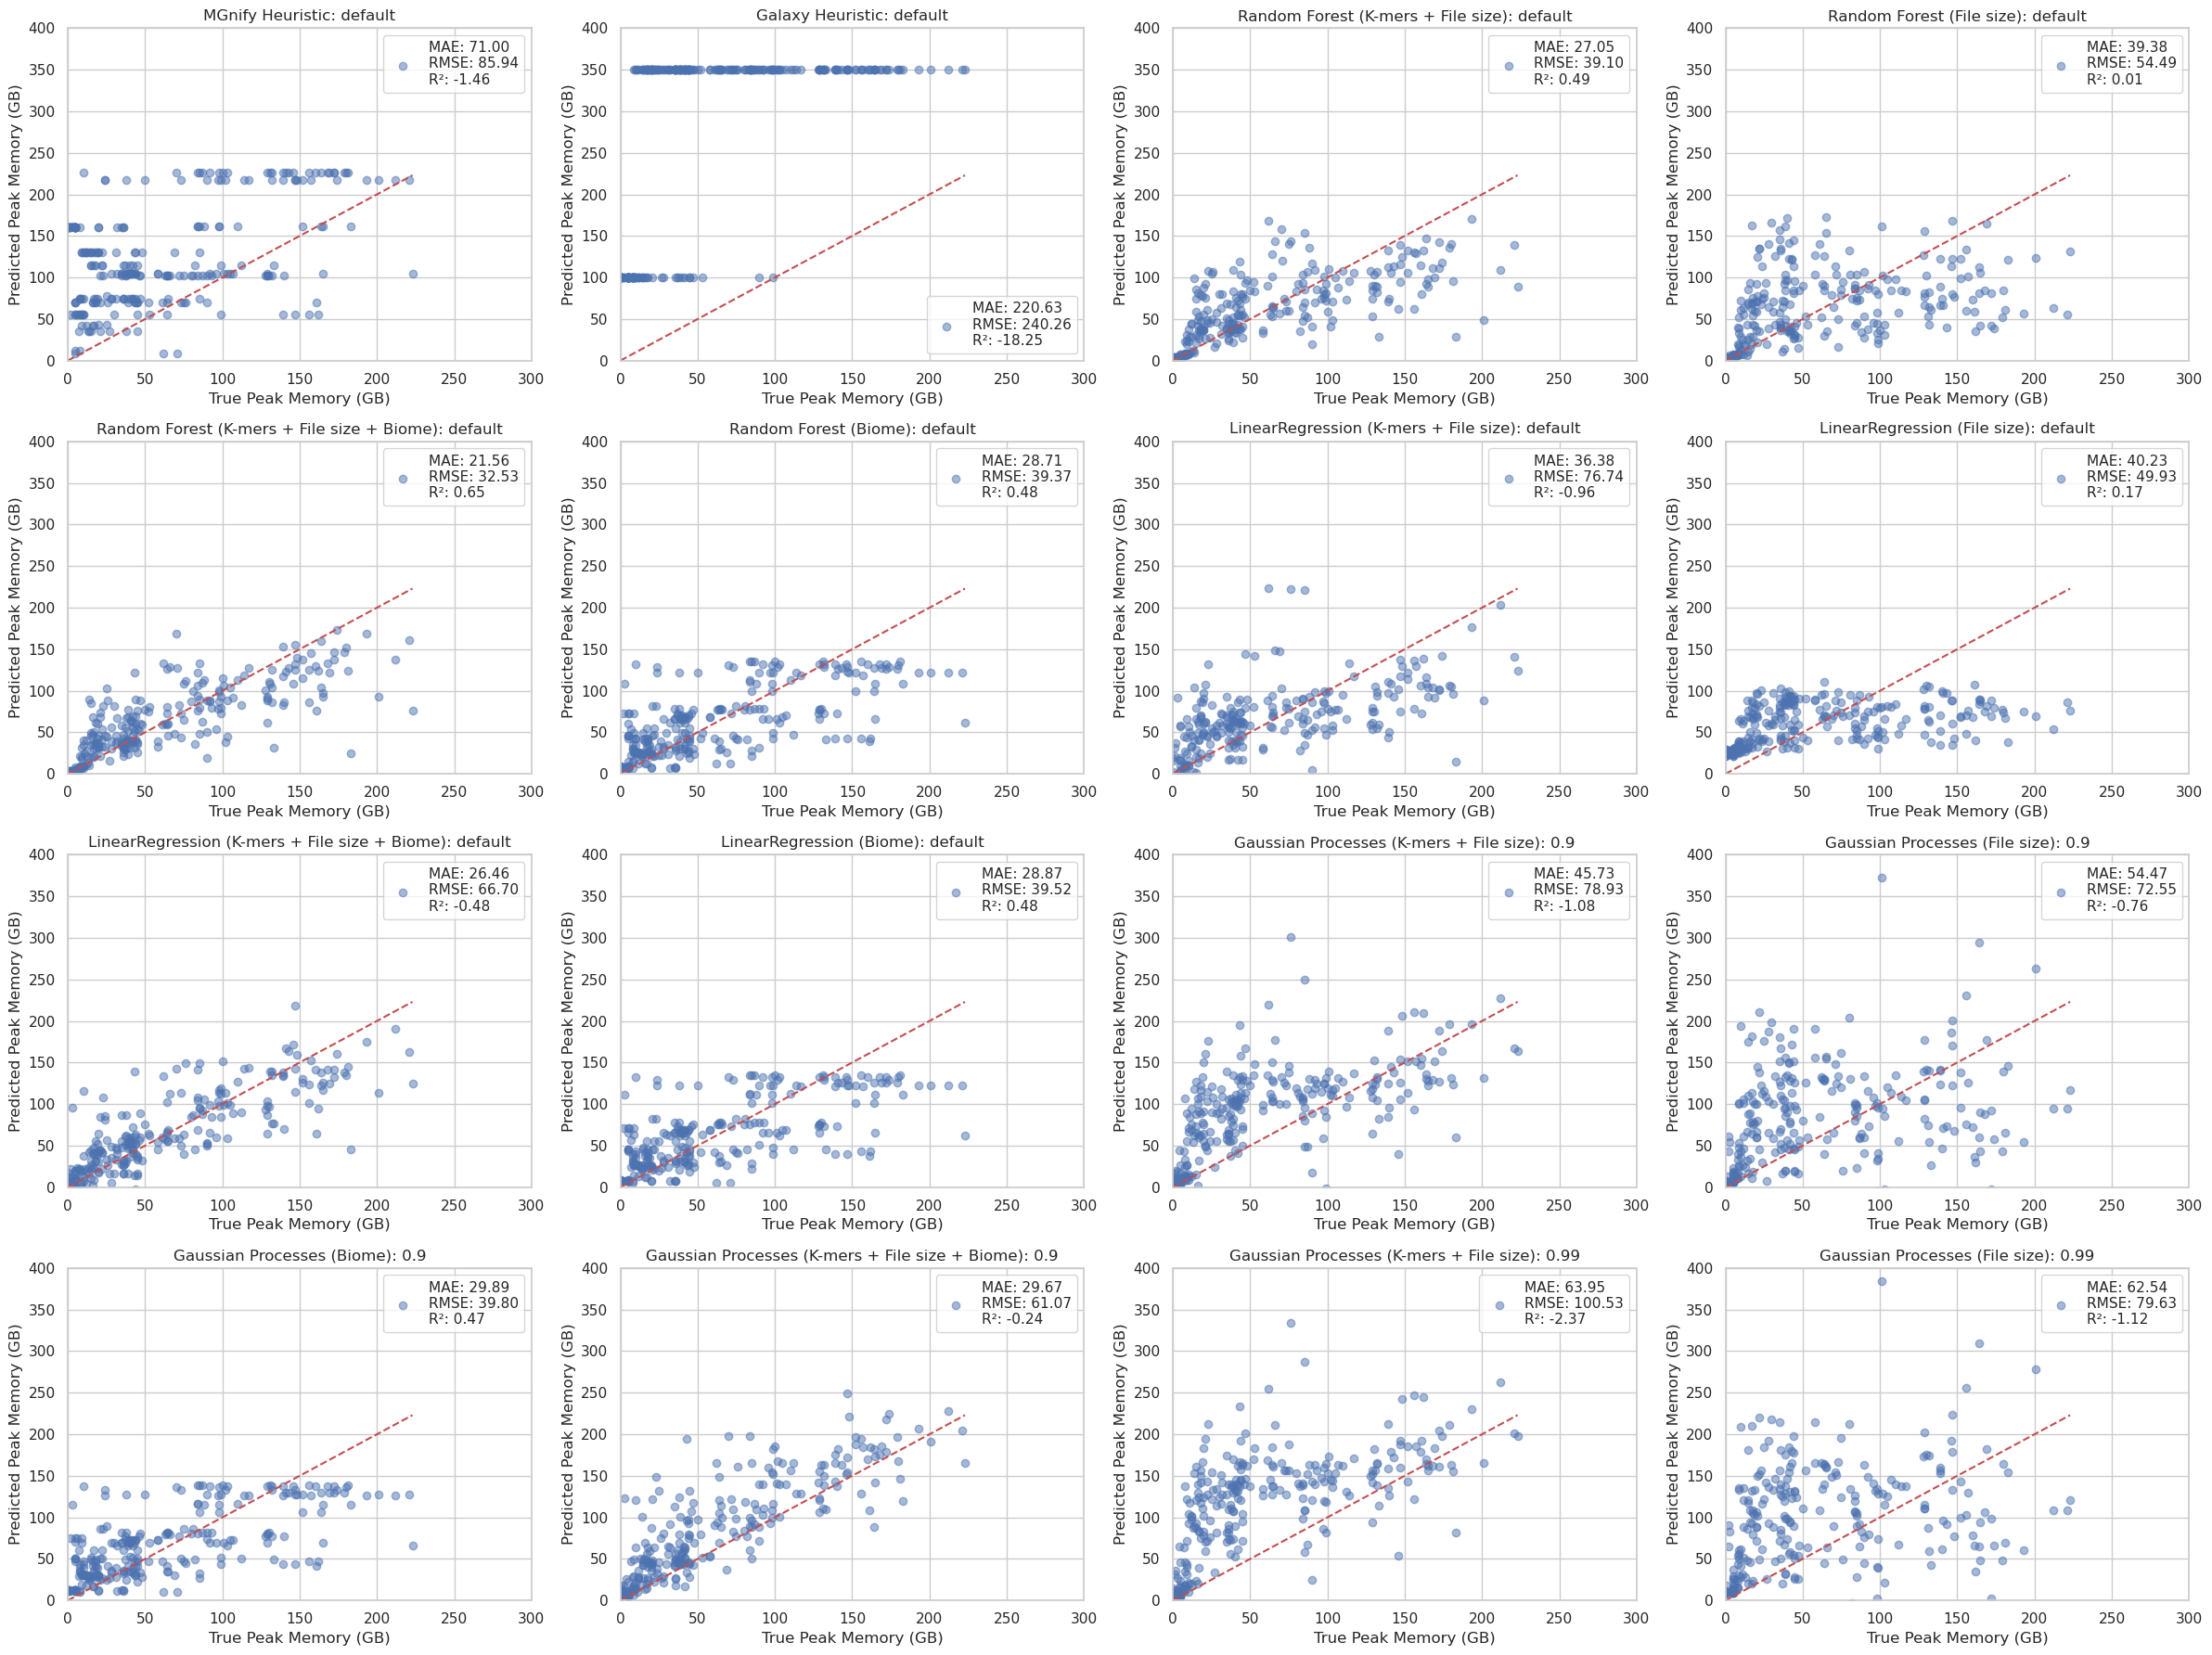

In [15]:
# 3 subplots with scatterplots of predictions vs true. where true = list(y) and pred = quant_results[keys]. The keys I want are [("Random Forest (All)","default"),("File size (Linear)","default"),("Gaussian Processes",0.9999)] 
# - draw diagonal, 
# - also calculate MAE, RMSE, and R² (show in legend)
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

keys = list(quant_results.keys())

# Create 3x4 grid
fig, axes = plt.subplots(4, 4, figsize=(6*4, 6*3))
axes = axes.flatten()  # flatten to iterate easily

# Plot the predictions
for ax, key in zip(axes, keys):
    preds = quant_results[key]
    ax.scatter(y, preds, alpha=0.5)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    ax.set_title(f"{key[0]}: {key[1]}")
    ax.set_xlabel("True Peak Memory (GB)")
    ax.set_ylabel("Predicted Peak Memory (GB)")
    
    # Metrics
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(np.mean((y - preds)**2))  # RMSE
    r2 = r2_score(y, preds)
    ax.legend([f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}"])
    
    # Set limits
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 400)

# Remove any unused axes if there are fewer keys than 12
for ax in axes[len(keys):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

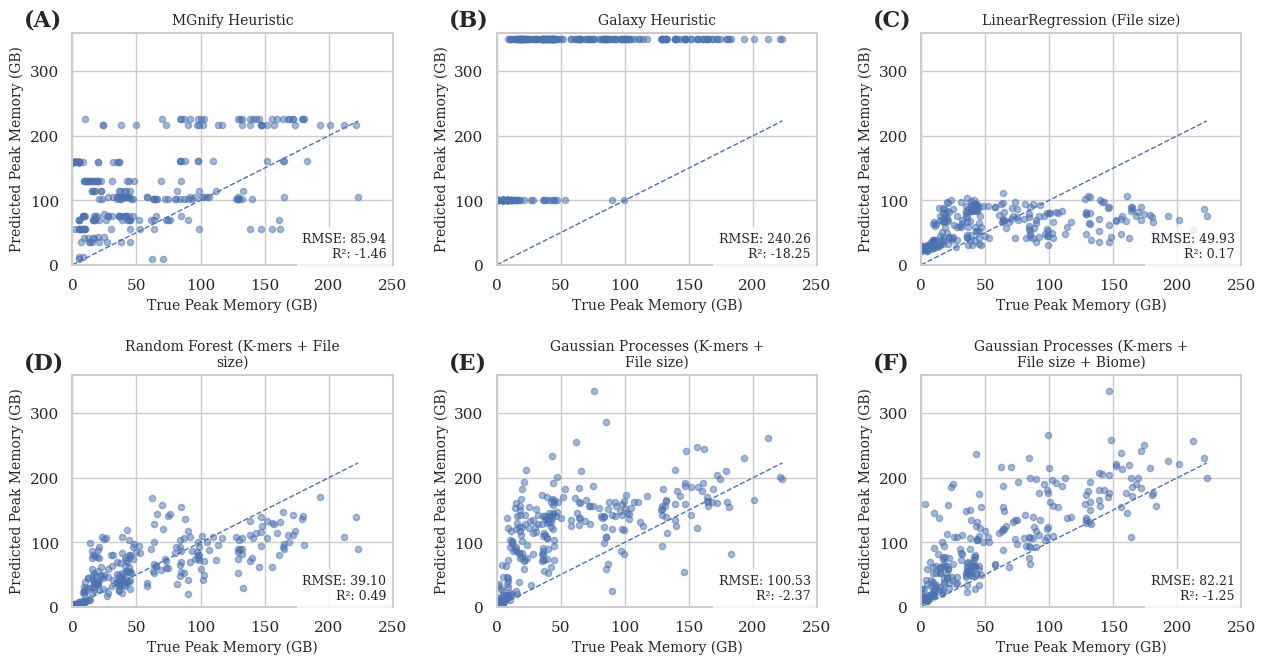

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import textwrap
import string

keys = [
    ('MGnify Heuristic', 'default'),
    ('Galaxy Heuristic', 'default'),
    ('LinearRegression (File size)', 'default'),
    ('Random Forest (K-mers + File size)', 'default'),
    ("Gaussian Processes (K-mers + File size)", 0.99),
    ("Gaussian Processes (K-mers + File size + Biome)", 0.99),
]

# Slightly taller for publication proportions
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

panel_labels = list(string.ascii_uppercase)

for i, (ax, key) in enumerate(zip(axes, keys)):
    preds = quant_results[key]

    # Scatter
    ax.scatter(y, preds, alpha=0.5, s=20)

    # Subtle diagonal reference
    ax.plot(
        [y.min(), y.max()],
        [y.min(), y.max()],
        linestyle="--",
        linewidth=1,
    )

    # Wrapped title (slightly smaller)
    wrapped_title = "\n".join(textwrap.wrap(key[0], width=28))
    ax.set_title(wrapped_title, fontsize=10)

    # Large panel label (journal style)
    ax.text(
        -0.15, 1.10,
        f"({panel_labels[i]})",
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left'
    )

    ax.set_xlabel("True Peak Memory (GB)", fontsize=10)
    ax.set_ylabel("Predicted Peak Memory (GB)", fontsize=10)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    ax.text(
        0.98, 0.02,
        f"RMSE: {rmse:.2f}\nR²: {r2:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        ha='right',
        va='bottom',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    ax.set_xlim(0, 250)
    ax.set_ylim(0, 360)

# Remove unused axes if any
for ax in axes[len(keys):]:
    fig.delaxes(ax)

plt.tight_layout()

# High-resolution export
plt.savefig("plots/memory_prediction_comparison.svg", dpi=600, bbox_inches="tight")
plt.savefig("plots/memory_prediction_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

Further analysis showed that all models struggled with high-memory jobs.

Underestimation led to failed jobs, while overestimation wasted memory on smaller ones.

---

## Rethinking what “good” looks like

A better evaluation should reflect the true cost per job, not just error magnitude between the prediction and the true peak memory.

That cost includes wasted allocations, retry attempts, and the duaration of asked allocations.

Considering these factors, we defined a cost function:
$$
C(y; a_0) = 
\underbrace{\sum_{r=0}^{R-1} C_{\text{fail}}(y, a_r)}_{\text{cost of retries}} 
+ 
\underbrace{C_{\text{over}}(y, a_R)}_{\text{waste on the successful attempt}}
$$
Where:
\[
\begin{aligned}
y &:\ \text{true peak memory use} \\
a_0 &:\ \text{initial memory allocation} \\
a_r &:\ \text{allocation on retry } r \\
R &:\ \text{total number of retries until success} \\
a_R &:\ \text{allocation on successful attempt} \\
C_{\text{fail}}(y, a_r) &:\ \text{cost incurred when a job fails due to under-allocation} \\
C_{\text{over}}(y, a_R) &:\ \text{cost incurred from over-allocation on the successful attempt}
\end{aligned}
\]

Using this function we can simulate the total cost of running jobs under different prediction models and allocation strategies.

For example, a model that underpredicts slightly might cause multiple retries — each consuming more total resources than a single, slightly overpredicted allocation.

**High accuracy of peak memory prediction doesn’t guarantee lower waste**.

We visualise this effect when a job’s true memory use is 120 GB, different starting allocations lead to very different total resource costs. Small prediction errors can multiply into large operational waste.

__Figure:__ Illustration of job memory usage over time.  
Each bar shows a single job attempt, where **height** represents memory usage and **width** represents wall time.  
The **total shaded area** corresponds to the overall resource cost until the job completes successfully. **Dark blue** indicates true memory used, while **light blue** shows wasted allocation.


In [16]:
# Example usage

# dummy_policy = lambda R, a0: a0*2**(R)
dummy_policy = lambda R, a0: a0*(R+1)
y_true = 120.0  # True peak memory in GB
true_wall_time = 50.0  # True wall time in hours

# list of simulated initial allocation
allocations = [25.0, 110.0, 160.0]


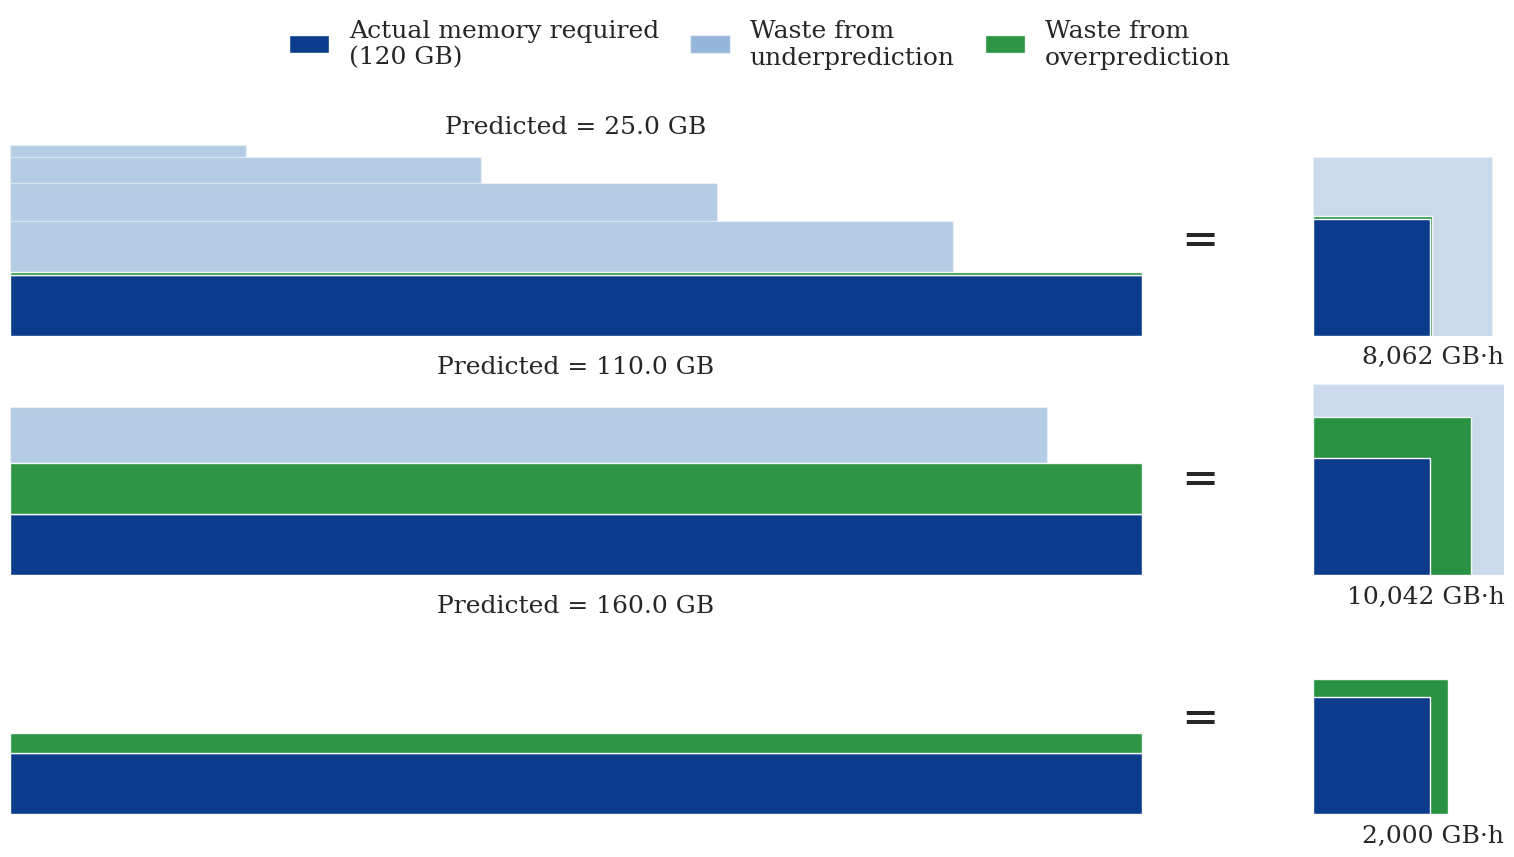

In [45]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import numpy as np

# ------------------ Global Style ------------------
BASE_FONTSIZE = 18
plt.rcParams.update({
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "legend.fontsize": BASE_FONTSIZE,
    "font.family": "serif",
    "axes.linewidth": 1.5
})

def kill_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("left", "right", "top", "bottom"):
        ax.spines[side].set_visible(False)

# ------------------ Gather results ------------------
runs = []
max_job_width = 0.0
max_total_height = 0.0
max_outer_side = 0.0

inner_side = np.sqrt(y_true * true_wall_time)

for a0 in allocations:
    result = JobCost.job_cost(y_true, true_wall_time, dummy_policy, a0)
    runs.append((a0, result))

    max_job_width = max(
        max_job_width,
        max([w for w, _ in result["failed_alloc_time"]] + [true_wall_time])
    )

    total_h = sum(h for _, h in result["failed_alloc_time"]) + result["a_R"]
    max_total_height = max(max_total_height, total_h)

    max_outer_side = max(
        max_outer_side,
        np.sqrt(result["total_mem_rate"])
    )

# ------------------ Layout ------------------
n = len(runs)
fig = plt.figure(figsize=(20.0, 2.9 * n))
gs = fig.add_gridspec(
    nrows=n,
    ncols=3,
    width_ratios=[4.3, 0.25, 1.15],
    wspace=0.05,
    hspace=0.25
)

# Colors
COLOR_ACTUAL = "#0b3c8c"
COLOR_UNDER = "#2c6fb7"
COLOR_OVER = "#178a2f"

for i, (a0, result) in enumerate(runs):
    axL = fig.add_subplot(gs[i, 0])
    axE = fig.add_subplot(gs[i, 1])
    axR = fig.add_subplot(gs[i, 2])

    total_h = sum(h for _, h in result["failed_alloc_time"]) + result["a_R"]
    y_top = total_h

    # ------------------ LEFT: Timeline ------------------
    for w, h in result["failed_alloc_time"]:
        y_top -= h
        axL.add_patch(Rectangle(
            (0, y_top), w, h,
            facecolor=COLOR_UNDER,
            alpha=0.35
        ))

    axL.add_patch(Rectangle(
        (0, 0), true_wall_time, y_true,
        facecolor=COLOR_ACTUAL,
        alpha=1.0
    ))

    if result["a_R"] > y_true:
        axL.add_patch(Rectangle(
            (0, y_true),
            true_wall_time,
            result["a_R"] - y_true,
            facecolor=COLOR_OVER,
            alpha=0.9
        ))

    axL.set_xlim(0, max_job_width)
    axL.set_ylim(0, max_total_height)
    axL.set_title(f"Predicted = {a0:.1f} GB", pad=8)
    kill_axes(axL)

    # Equal sign
    kill_axes(axE)
    axE.text(0.5, 0.5, "=", ha="center", va="center", fontsize=32)

    # ------------------ RIGHT: Area Squares ------------------

    outer_under = np.sqrt(result["total_mem_rate"])
    inner_actual = inner_side

    axR.add_patch(Rectangle(
        (0, 0),
        outer_under,
        outer_under,
        facecolor=COLOR_UNDER,
        alpha=0.25
    ))

    if result["a_R"] > y_true:
        over_side = np.sqrt(true_wall_time * result["a_R"])
        axR.add_patch(Rectangle(
            (0, 0),
            over_side,
            over_side,
            facecolor=COLOR_OVER,
            alpha=0.9
        ))

    axR.add_patch(Rectangle(
        (0, 0),
        inner_actual,
        inner_actual,
        facecolor=COLOR_ACTUAL,
        alpha=1.0
    ))

    axR.set_xlim(0, max_outer_side)
    axR.set_ylim(0, max_outer_side)
    axR.set_aspect('equal')
    kill_axes(axR)

    axR.text(
        max_outer_side,
        -0.05 * max_outer_side,
        f"{result['total_waste_rate']:,.0f} GB·h",
        ha="right",
        va="top",
        fontsize=BASE_FONTSIZE
    )

# ------------------ Legend ------------------
legend_elements = [
    Patch(
        facecolor=COLOR_ACTUAL,
        label=f"Actual memory required\n({y_true:.0f} GB)"
    ),
    Patch(
        facecolor=COLOR_UNDER,
        alpha=0.5,
        label="Waste from\nunderprediction"
    ),
    Patch(
        facecolor=COLOR_OVER,
        alpha=0.9,
        label="Waste from\noverprediction"
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05),
    columnspacing=1.2,
    handlelength=1.6,
    handletextpad=0.8
)

plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.savefig("plots/retry_example.svg", dpi=600, bbox_inches="tight")
plt.show()

---

## What the results show

When we compared all models using cost-based metrics—total memory usage waste, total wall time, and failure rate —based on real production distribution, the results changed.

In [26]:

# --- 0) Prepare true wall time ---
erz_to_wall_time = dict(zip(mgnify_dataset["primary_accession"], mgnify_dataset["wall_clock_seconds"]))
training_df_wall_time = (np.array([erz_to_wall_time.get(err_to_erz.get(srr,"")) for srr in df.index]) / 60) / 60  # in hours

# --- 1) Prepare data ---
real_logs_peak_memory = mgnify_dataset["peak_mem_in_gbs"].to_numpy()
sample_true = y.to_numpy()
base_wall_time = training_df_wall_time
retry_policy = lambda R, a0: (R+1) * a0

key = quant_results.keys()
keys = [
    ('MGnify Heuristic', 'default'),
    ('Galaxy Heuristic', 'default'),
    ('LinearRegression (File size)', 'default'),
    ('Random Forest (Biome)', 'default'),
    ('Random Forest (K-mers + File size)', 'default'),
    ('Random Forest (K-mers + File size + Biome)', 'default'),
    ("Gaussian Processes (Biome)", 0.99),
    ("Gaussian Processes (K-mers + File size)", 0.99),
    ("Gaussian Processes (K-mers + File size + Biome)", 0.99),
]


# Use **all predictors from quant_results**, plus a Dummy predictor
predictors: Dict[str, np.ndarray] = {f"{x[0]} {x[1]}": quant_results[x] for x in keys}

# Add a naive "Dummy" predictor
# naive_mean = int(np.mean(real_logs_peak_memory))
# predictors[f"Dummy {naive_mean} GB"] = np.full_like(sample_true, naive_mean)

# Ensure no predictions are below 1GB
for k in predictors:
    predictors[k] = np.maximum(1.0, predictors[k])

# --- 2) Build evaluator ---
ev = HPCMemoryEvaluator(
    sample_peak_true=sample_true,
    pop_peak_true=real_logs_peak_memory,
    predictors=predictors,
    total_waste_fn=lambda mem_true, time_true, mem_pred: JobCost.batch_job_total_waste_rate(mem_true, time_true, retry_policy, mem_pred),
    total_wall_time_fn=lambda mem_true, time_true, mem_pred: JobCost.batch_job_total_time(mem_true, time_true, retry_policy, mem_pred),
    base_wall_time=base_wall_time,
    weighting_cfg=WeightingConfig(nbins=60, log_scale=True),
)

# --- 3) Run evaluation ---
ev.compute_importance_weights()
summary_df, draws = ev.evaluate(n_jobs=1000, n_iter=4000, seed=123)

# --- 4) Show results ---
print(summary_df.to_markdown(index=False))

| predictor                                            |   waste_per_1000_mean |   waste_per_1000_lo |   waste_per_1000_hi |   wall_per_1000_mean |   wall_per_1000_lo |   wall_per_1000_hi |   failure_rate_mean |   failure_rate_lo |   failure_rate_hi |
|:-----------------------------------------------------|----------------------:|--------------------:|--------------------:|---------------------:|-------------------:|-------------------:|--------------------:|------------------:|------------------:|
| MGnify Heuristic default                             |           3.27232e+06 |         2.40202e+06 |         4.46338e+06 |              50020.7 |            37389.7 |            67498   |           0.0367923 |          0.026    |             0.048 |
| Galaxy Heuristic default                             |           9.03161e+06 |         7.68404e+06 |         1.08031e+07 |              38938.5 |            31878.6 |            47861   |           0         |          0        |             

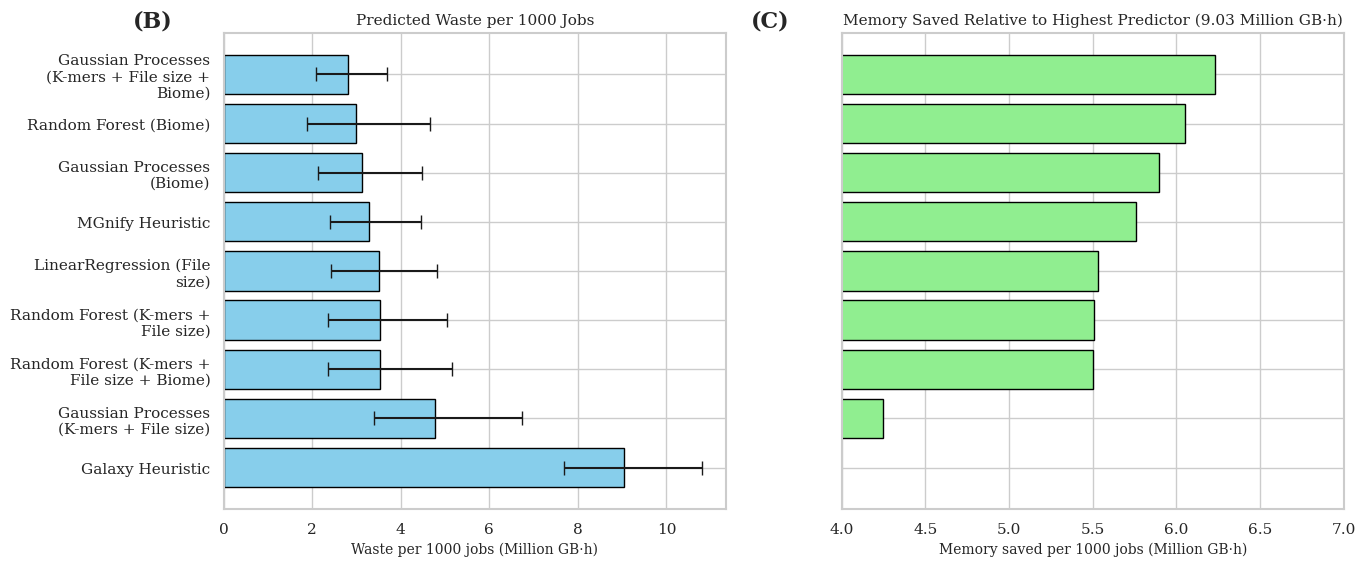

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import textwrap
import string

# --- 1) Function to shorten/wrap labels ---
def shorten_label(label, width=25):
    parts = label.split()
    if len(parts) > 1:
        parts = parts[:-1]  # remove last word
    main_label = " ".join(parts)
    return "\n".join(textwrap.wrap(main_label, width))

# --- 2) Sort dataframe by mean waste descending ---
summary_sorted = summary_df.sort_values("waste_per_1000_mean", ascending=False)

# --- 3) Compute symmetric error for matplotlib ---
error = [
    summary_sorted["waste_per_1000_mean"] - summary_sorted["waste_per_1000_lo"],
    summary_sorted["waste_per_1000_hi"] - summary_sorted["waste_per_1000_mean"]
]

# --- 4) Shorten and wrap labels ---
labels = [shorten_label(l) for l in summary_sorted["predictor"]]

# --- 5) Compute memory saved relative to highest predictor ---
highest_waste = summary_sorted["waste_per_1000_mean"].max()
saved_memory = highest_waste - summary_sorted["waste_per_1000_mean"]

# --- 6) Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
panel_labels = ["B", "C"]  # for figure labeling

# --- 6a) Plot (B): Waste per 1000 jobs ---
axes[0].barh(
    labels,
    summary_sorted["waste_per_1000_mean"] / 1e6,  # Million GB·h
    xerr=[e / 1e6 for e in error],
    capsize=5,
    color="skyblue",
    edgecolor="black"
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Waste per 1000 jobs (Million GB·h)", fontsize=10)
axes[0].set_title("Predicted Waste per 1000 Jobs", fontsize=11)

# Add panel label
axes[0].text(
    -0.18, 1.05,
    f"({panel_labels[0]})",
    transform=axes[0].transAxes,
    fontsize=16,
    fontweight='bold',
    va='top',
    ha='left'
)

# --- 6b) Plot (C): Memory saved relative to highest predictor ---
axes[1].barh(
    labels,
    saved_memory / 1e6,  # Million GB·h
    color="lightgreen",
    edgecolor="black"
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Memory saved per 1000 jobs (Million GB·h)", fontsize=10)
axes[1].set_title(f"Memory Saved Relative to Highest Predictor ({highest_waste/1e6:.2f} Million GB·h)", fontsize=11)
axes[1].set_xlim(4, 7)  # limit x-axis

# Add panel label
axes[1].text(
    -0.18, 1.05,
    f"({panel_labels[1]})",
    transform=axes[1].transAxes,
    fontsize=16,
    fontweight='bold',
    va='top',
    ha='left'
)

plt.tight_layout()

# Optional: High-resolution export
plt.savefig("plots/waste_memory_side_by_side.svg", dpi=600, bbox_inches="tight")
plt.show()

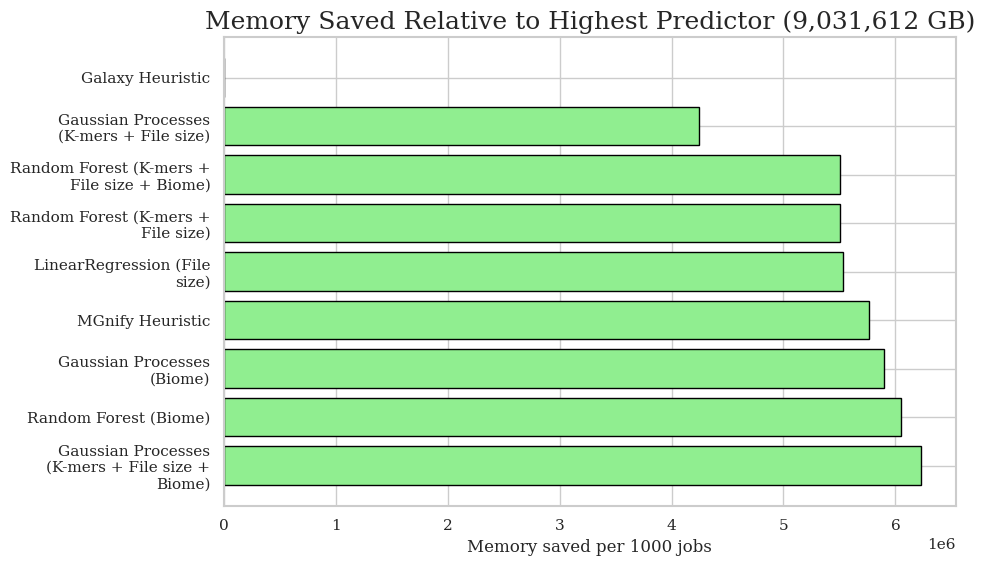

In [34]:
# --- Second plot: Memory saved relative to highest predictor ---
highest_waste = summary_sorted["waste_per_1000_mean"].max()
saved_memory = highest_waste - summary_sorted["waste_per_1000_mean"]

plt.figure(figsize=(10, 6))
plt.barh(
    labels,
    saved_memory,
    color="lightgreen",
    edgecolor="black"
)
plt.xlabel("Memory saved per 1000 jobs")
plt.title(f"Memory Saved Relative to Highest Predictor ({highest_waste:,.0f} GB)")
plt.gca().invert_yaxis()  # Keep same order as original chart
plt.tight_layout()
plt.show()

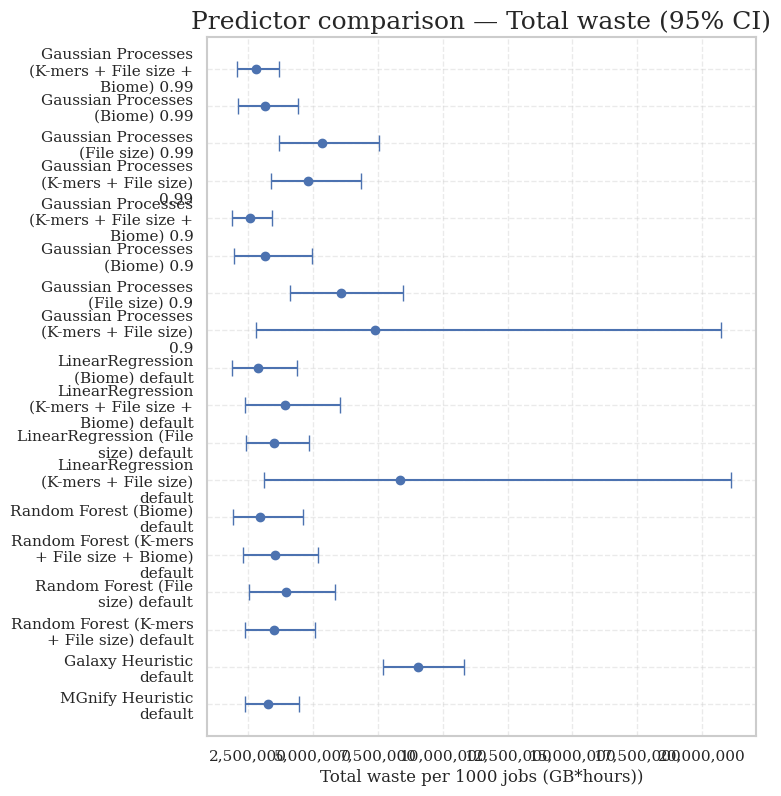

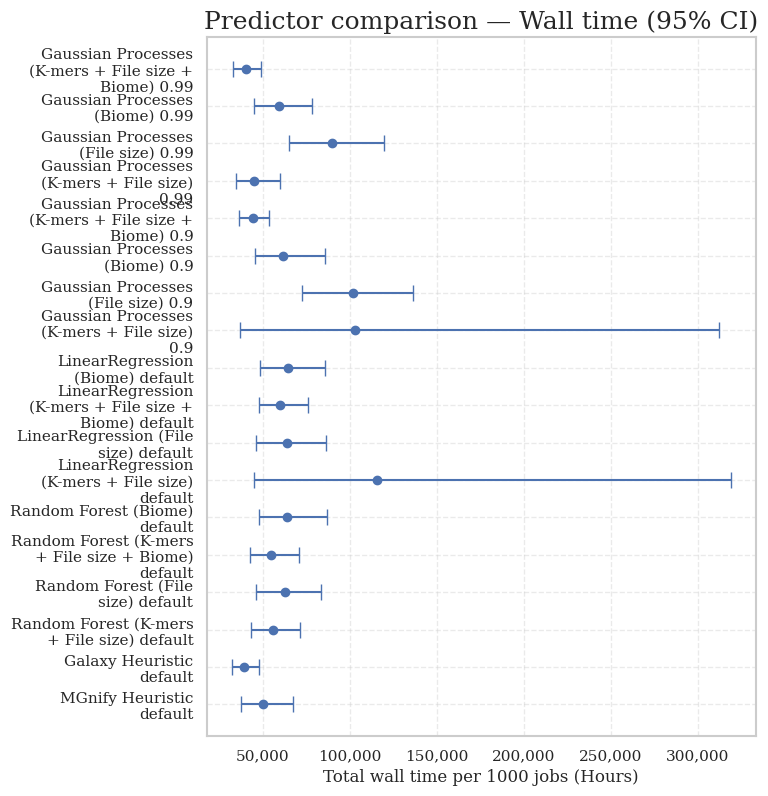

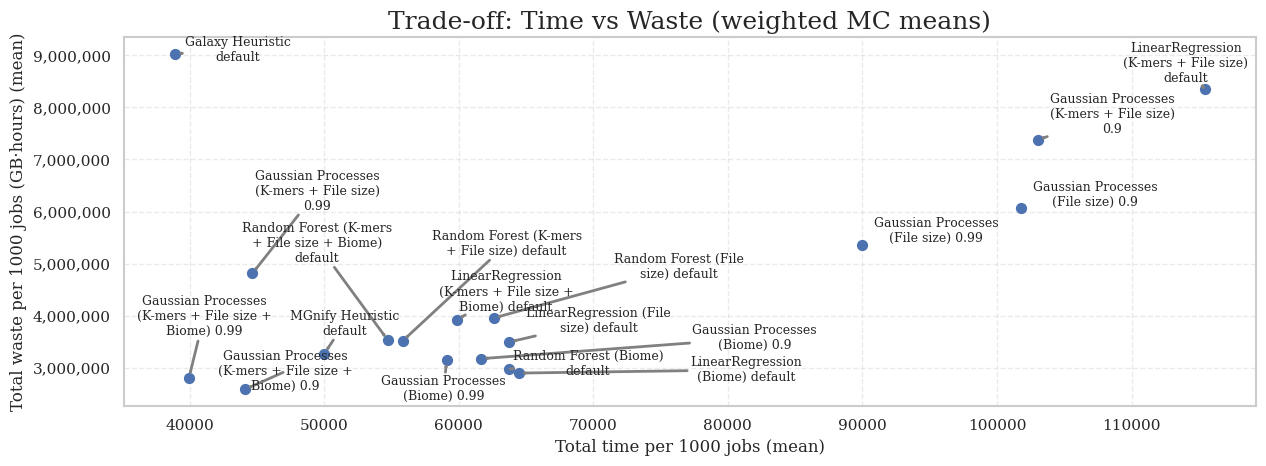

In [25]:

# Optional plots (require matplotlib)
ev.plot_errorbars(metric="waste")
ev.plot_errorbars(metric="wall")
# ev.plot_weighted_density(metric="waste", bins=50)
#ev.plot_mc_distribution(metric="waste", bins=40)
ev.plot_tradeoff()


# get HPCMemory for a range for all predictors

In [39]:
import numpy as np
from typing import Dict

# --- 1) True data ---
erz_to_wall_time = dict(zip(mgnify_dataset["primary_accession"], mgnify_dataset["wall_clock_seconds"]))
training_df_wall_time = (np.array([erz_to_wall_time.get(err_to_erz.get(srr,"")) for srr in df.index]) / 60) / 60  # in hours

real_logs_peak_memory = mgnify_dataset["peak_mem_in_gbs"].to_numpy()               
sample_true = y.to_numpy()            
base_wall_time = training_df_wall_time

# retry policy
retry_policy = lambda R, a0: (R+1)*a0  # current policy

# --- 2) Base predictors from quant_results ---
predictors: Dict[str, np.ndarray] = {}
for key in quant_results.keys():
    pred_array = np.maximum(1.0, quant_results[key])  # floor to 1GB
    predictors[f"{key[0]} {key[1]}"] = pred_array

# --- 3) Add offsets from -100GB to +200GB in 10GB steps ---
offsets = np.arange(-20, 76, 5)  # -100, -90, ..., +200
offsets = [0]
new_predictors = {}
for name, preds in predictors.items():
    for offset in offsets:
        # make sure predictions don't go below 1GB
        shifted_preds = np.maximum(1.0, preds + offset)
        new_predictors[f"{name} {offset:+}GB"] = shifted_preds

# Merge shifted predictors into main dictionary
predictors.update(new_predictors)

# --- 4) Add naive mean predictor ---
# naive_mean = int(np.mean(real_logs_peak_memory))
# predictors[f"Dummy {naive_mean} GB"] = np.full_like(sample_true, naive_mean)

# --- 5) Build evaluator ---
ev = HPCMemoryEvaluator(
    sample_peak_true=sample_true,
    pop_peak_true=real_logs_peak_memory,
    predictors=predictors,
    total_waste_fn=lambda mem_true,time_true,mem_pred: JobCost.batch_job_total_waste_rate(mem_true,time_true,retry_policy,mem_pred),      
    total_wall_time_fn=lambda mem_true,time_true,mem_pred: JobCost.batch_job_total_time(mem_true,time_true,retry_policy,mem_pred),       
    base_wall_time=base_wall_time,
    weighting_cfg=WeightingConfig(nbins=60, log_scale=True),
)

# --- 6) Run evaluation ---
ev.compute_importance_weights()
summary_df, draws = ev.evaluate(n_jobs=1000, n_iter=4000, seed=123)

# --- 7) Show summary ---
print(summary_df.to_markdown(index=False))

KeyboardInterrupt: 

# plot predictors vs offset

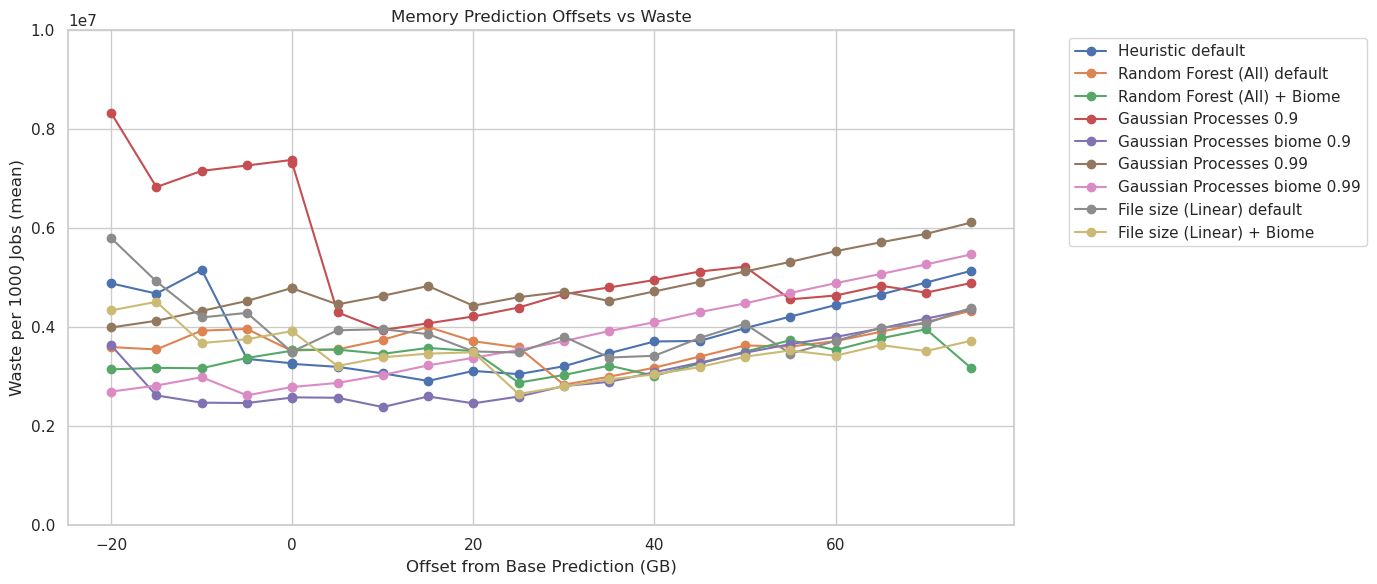

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np

# --- 1) Extract offsets from predictor names ---
def extract_offset(predictor_name: str):
    """Extract numeric offset from predictor string, e.g., 'Random Forest (All) default +10GB' -> 10"""
    match = re.search(r"([+-]?\d+)GB", predictor_name)
    if match:
        return int(match.group(1))
    else:
        return 0  # default / no offset

summary_df['offset_GB'] = summary_df['predictor'].apply(extract_offset)

# --- 2) Extract base predictor names (remove offset) ---
def base_predictor_name(predictor_name: str):
    return re.sub(r"[+-]?\d+GB", "", predictor_name).strip()

summary_df['base_predictor'] = summary_df['predictor'].apply(base_predictor_name)

# --- 3) Plot ---
plt.figure(figsize=(14, 6))

for base in summary_df['base_predictor'].unique():
    df_base = summary_df[summary_df['base_predictor'] == base].copy()
    df_base = df_base.sort_values('offset_GB')  # sort by offset
    plt.plot(df_base['offset_GB'], df_base['waste_per_1000_mean'], marker='o', label=base)

plt.xlabel("Offset from Base Prediction (GB)")
plt.ylabel("Waste per 1000 Jobs (mean)")
plt.title("Memory Prediction Offsets vs Waste")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.ylim(0, 10000000)
plt.tight_layout()
plt.show()

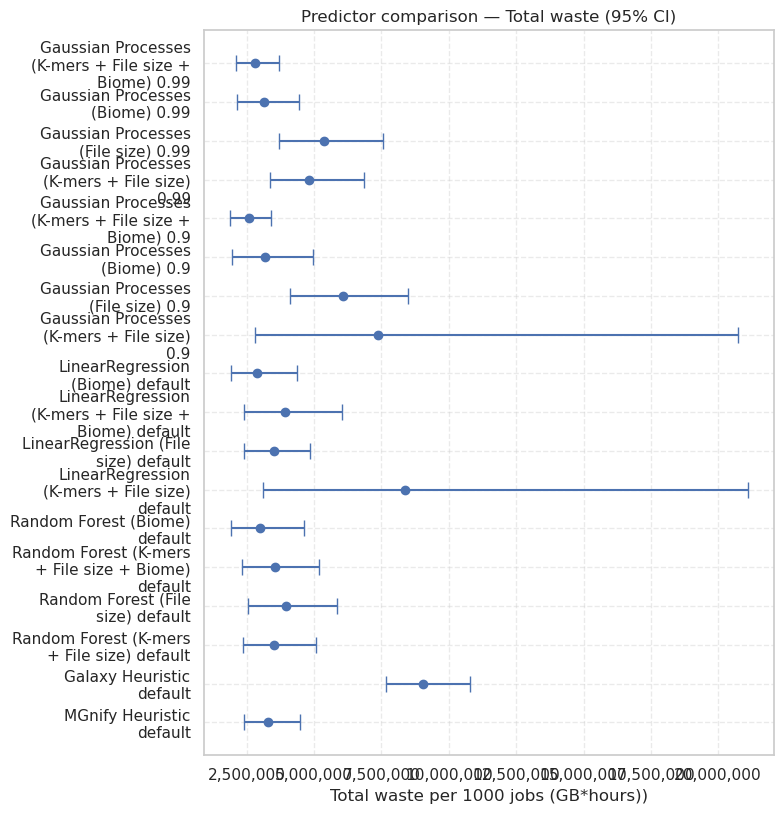

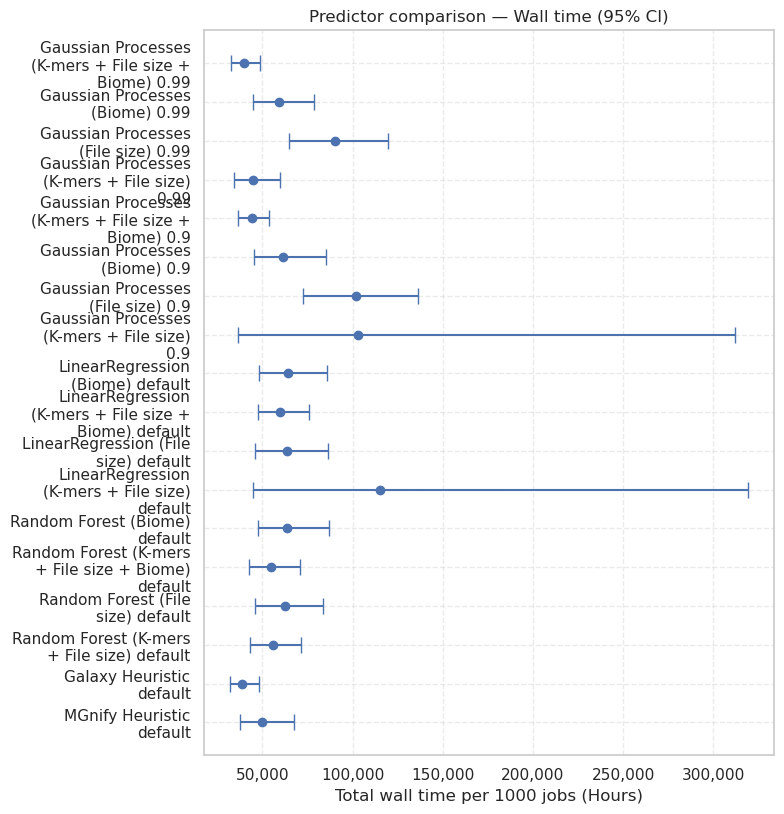

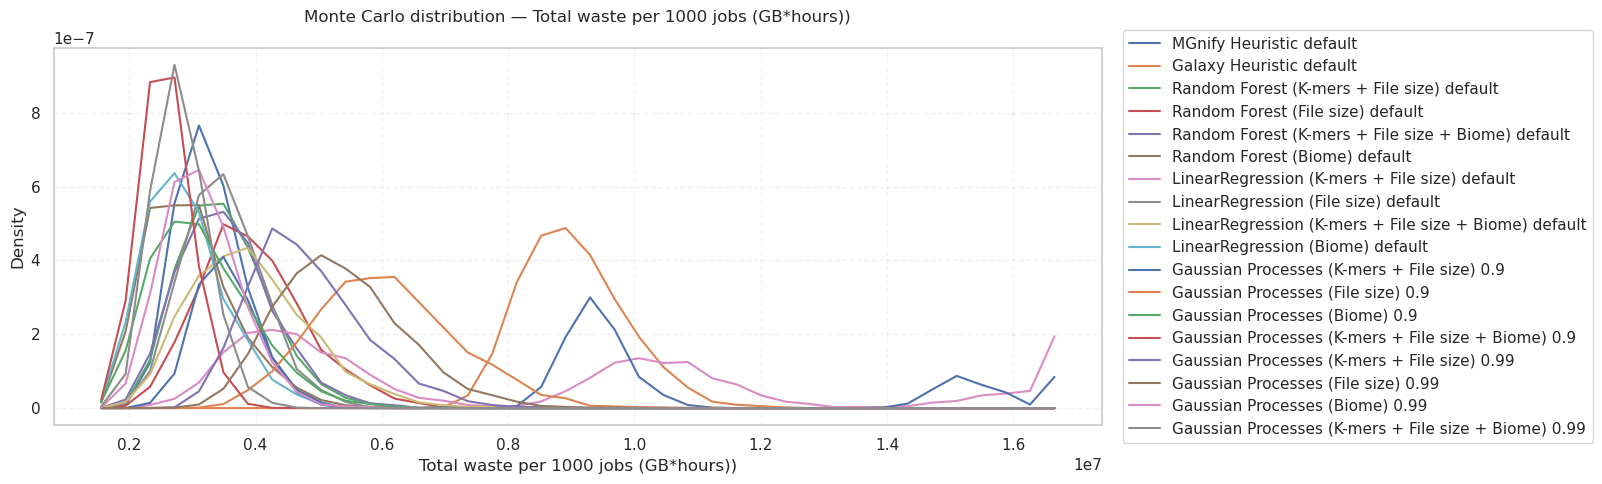

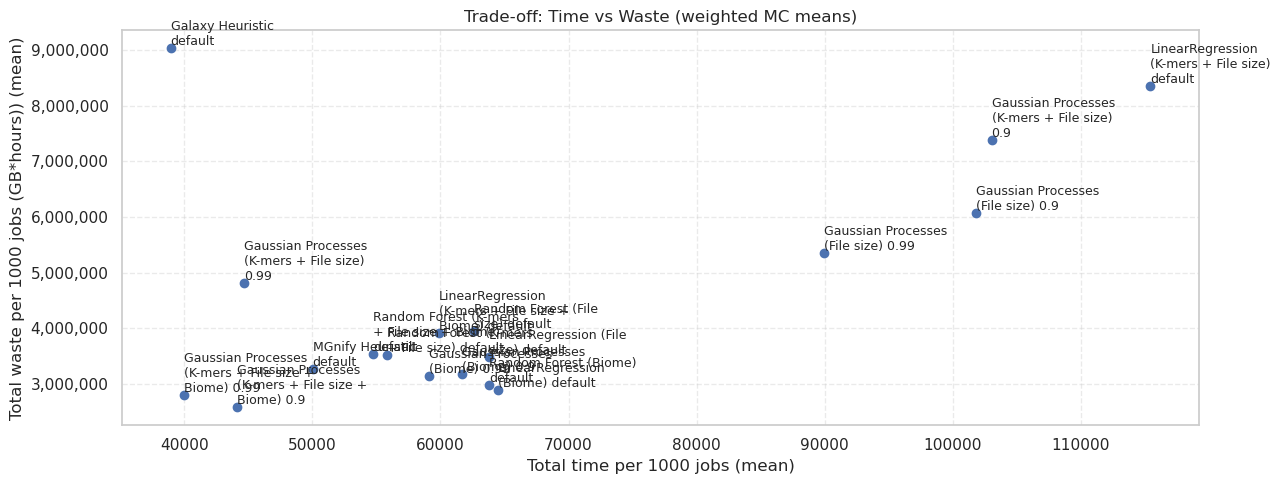

In [32]:

# Optional plots (require matplotlib)
ev.plot_errorbars(metric="waste")
ev.plot_errorbars(metric="wall")
# ev.plot_weighted_density(metric="waste", bins=50)
ev.plot_mc_distribution(metric="waste", bins=40)
ev.plot_tradeoff()


Despite its strong MAE and R², the Random Forest model did not outperform the current heuristic in total waste.

However, integrating biome as feature (Gaussian Processes) showed promising results.

---

## What this means for us

If we continue to rely on traditional metrics, we risk selecting models that look good in tests but cost more in production.

Model evaluation must account for how jobs are distributed and how systems recover from errors.

By incorporating real workload distributions, memory-time usage, and retry costs, we can design metrics that reward what truly matters: fewer failures and lower total waste.

Message to take away: Re-evaluate model selection under these realistic conditions.

## Next steps

- Collect more real job data to better represent actual workloads.
- Include failed job logs to improve model training.
- Define and test cost-aware evaluation metrics that combine accuracy, retry behavior, and operational efficiency. This could also help with training loss functions.
- Explore adaptive allocation strategies that adjust based on past job performance.
- Better metrics mean better models — and better use of HPC systems.